In [1]:
import pandas as pd


df = pd.read_json("data/extraction_pdf/datasets/SUMMARY/results_summary_task4.json", lines=True)

In [2]:
df

,file_name,total_samples,total_original_samples,str_accuracy,str_probs,accuracy,accuracy_std,probs_mean,probs_std
0,task4_20251005_044742_gemma-2-9b-it.jsonl,2040,2040,0.51_±_0.01,0.93_±_0.18,0.509314,0.011068,0.929983,0.182476
1,task4_20251003_230112_gemma-2-2b-it.jsonl,2040,2040,0.50_±_0.01,0.84_±_0.23,0.496078,0.011070,0.836852,0.229890
2,task4_20251009_215615_gpt-5.jsonl,919,919,0.61_±_0.02,0.00_±_0.00,0.608270,0.016102,0.000000,0.000000
3,task4_20251004_025330_Qwen3-30B-A3B-Instruct-2...,2040,2040,0.54_±_0.01,0.95_±_0.13,0.544608,0.011026,0.950342,0.128577
4,task4_20251004_060758_gemma-3-27b-it.jsonl,2040,2040,0.54_±_0.01,0.99_±_0.06,0.540196,0.011034,0.990722,0.061800
5,task4_20251004_062816_Llama-3.3-70B-Instruct.j...,2040,2040,0.51_±_0.01,0.99_±_0.08,0.509314,0.011068,0.985192,0.076597
6,task4_20251004_224238_Llama-3.2-3B-Instruct.jsonl,2040,2040,0.47_±_0.01,0.77_±_0.23,0.475000,0.011056,0.765313,0.232278
7,task4_20251004_230740_Llama-3.2-1B-Instruct.jsonl,2040,2040,0.51_±_0.01,0.78_±_0.23,0.511275,0.011067,0.780975,0.227114
8,task4_20251005_004930_gemma-3-1b-it.jsonl,2040,2040,0.50_±_0.01,0.98_±_0.09,0.495588,0.011070,0.984796,0.087382
9,task4_20251005_011229_gemma-3-12b-it.jsonl,2040,2040,0.54_±_0.01,0.99_±_0.07,0.536275,0.011041,0.988217,0.065860


In [3]:
import pandas as pd

df = pd.read_json("data/performance_eval/task_eval_translation_20251006_125819_gemma-2-27b-it.jsonl", lines=True)
df = df[df["CometScore"]!=-1.0]
subset = df[~df["task_translation_dict"].isnull()][
    ["CometScore", "CometScoreSmall", "spbleu_score", "chrf_score"]
]

# 计算 mean 和 std
means = subset.mean()
stds = subset.std()
for col in subset.columns:
    result = f"{means[col]:.2f} ± {stds[col]:.2f}"
    print(f"{col}: {result}")


/tmp/ipykernel_1521109/3432882903.py:3: FutureWarning: Passing literal json to 'read_json' is deprecated and will be removed in a future version. To read from a literal string, wrap it in a 'StringIO' object.
  df = pd.read_json("data/performance_eval/task_eval_translation_20251006_125819_gemma-2-27b-it.jsonl", lines=True)


ValueError: Expected object or value

In [4]:
df.source.value_counts()

AttributeError: 'DataFrame' object has no attribute 'source'

In [5]:
import glob
for f in glob.glob("data/performance_eval/*"):
    if "task_eval_translation" in f:
        print (f)
        model_name = f.split("_")[-1].replace(".jsonl","")
        df = pd.read_json(f, lines=True)
        df = df[df["CometScore"]!=-1.0]
        print(f"Number of valid rows: {len(df)}")
        subset = df[~df["task_translation_dict"].isnull()][
            ["CometScore", "CometScoreSmall", "spbleu_score", "chrf_score"]
        ]
        CometScore = subset["CometScore"].mean()
        CometScoreSmall = subset["CometScoreSmall"].mean()
        spbleu_score = subset["spbleu_score"].mean()
        chrf_score = subset["chrf_score"].mean()
        means = subset.mean()
        stds = subset.std()
        print (f.split("/")[-1])
        for col in subset.columns:
            result = f"{means[col]:.2f} ± {stds[col]:.2f}"
            print(f"{col}: {result}")
        print ("----------------------")
     

data/performance_eval/task_eval_translation_20251008_074544_Llama-3.2-1B-Instruct.jsonl
Number of valid rows: 3197
task_eval_translation_20251008_074544_Llama-3.2-1B-Instruct.jsonl
CometScore: 0.08 ± 0.15
CometScoreSmall: 0.32 ± 0.13
spbleu_score: 1.72 ± 2.79
chrf_score: 13.16 ± 5.83
----------------------
data/performance_eval/task_eval_translation_20251006_004427_Qwen3-Next-80B-A3B-Instruct.jsonl
Number of valid rows: 3352
task_eval_translation_20251006_004427_Qwen3-Next-80B-A3B-Instruct.jsonl
CometScore: 0.26 ± 0.12
CometScoreSmall: 0.38 ± 0.10
spbleu_score: 19.15 ± 11.46
chrf_score: 40.31 ± 9.59
----------------------
data/performance_eval/task_eval_translation_20251006_221514_gemma-3-4b-it.jsonl
Number of valid rows: 3352
task_eval_translation_20251006_221514_gemma-3-4b-it.jsonl
CometScore: 0.14 ± 0.11
CometScoreSmall: 0.31 ± 0.08
spbleu_score: 10.09 ± 7.50
chrf_score: 31.07 ± 7.63
----------------------
data/performance_eval/task_eval_translation_20251006_002049_gemma-2-2b-it.jso

In [6]:
import glob
import pandas as pd
df_summary = pd.DataFrame()
for f in glob.glob("data/performance_eval/*"):
    if "task_eval_translation" in f:
        model_name = f.split("_")[-1].replace(".jsonl","")
        df = pd.read_json(f, lines=True)
        df = df[df["CometScore"]!=-1.0]
        # print(f"Number of valid rows: {len(df)}")
        subset = df[~df["task_translation_dict"].isnull()][
            ["CometScore", "CometScoreSmall", "spbleu_score", "chrf_score"]
        ]
        CometScore = subset["CometScore"].mean()
        CometScoreSmall = subset["CometScoreSmall"].mean()
        spbleu_score = subset["spbleu_score"].mean()
        chrf_score = subset["chrf_score"].mean()
        row_dict = {
            "model": model_name,
            "CometScore": f"{CometScore:.2f}",
            "CometScoreSmall": f"{CometScoreSmall:.2f}",
            "spbleu_score": f"{spbleu_score:.2f}",
            "chrf_score": f"{chrf_score:.2f}"
        }
        row_df = pd.DataFrame([row_dict])
        df_summary = pd.concat([df_summary, row_df], ignore_index=True)

/tmp/ipykernel_1521109/3354997929.py:200: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  plot_df["times"] = plot_df["times"].astype(int)


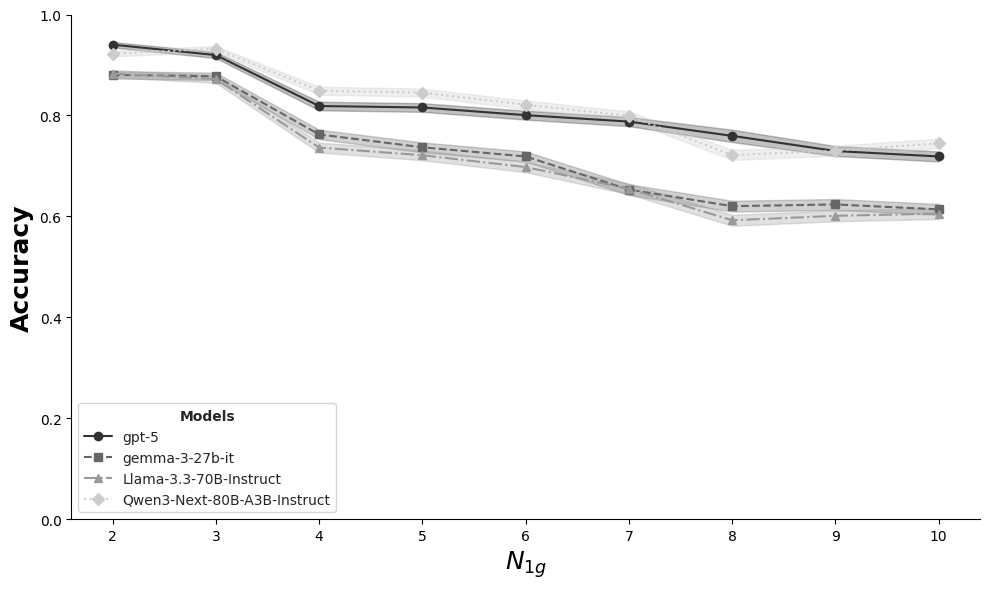

/tmp/ipykernel_1521109/3354997929.py:205: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  plot_df["times"] = plot_df["times"].astype(int)


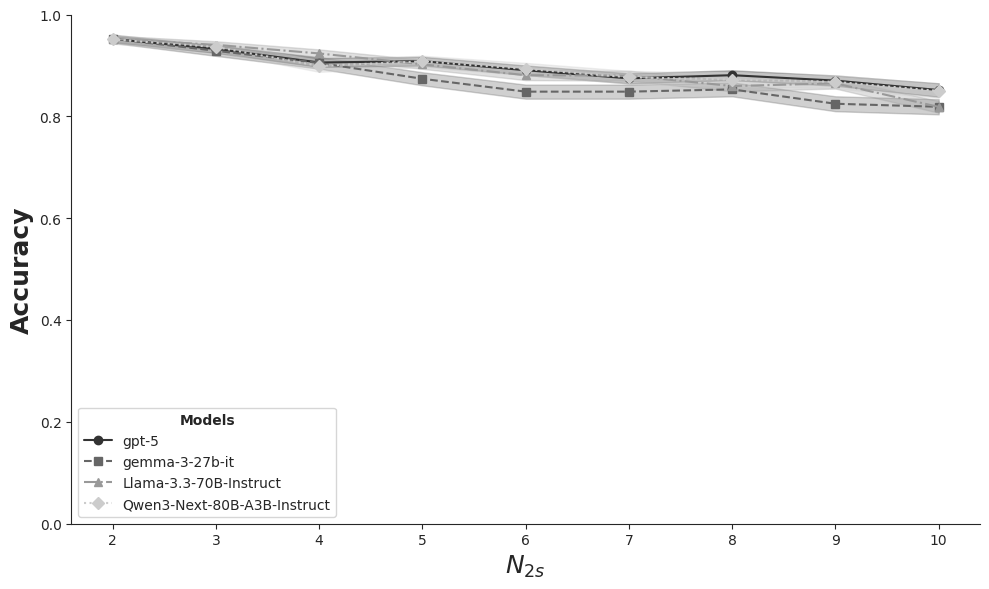

/tmp/ipykernel_1521109/3354997929.py:113: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  model_data[['part1', 'part2']] = model_data['times'].str.split('_', expand=True).astype(int)
/tmp/ipykernel_1521109/3354997929.py:113: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  model_data[['part1', 'part2']] = model_data['times'].str.split('_', expand=True).astype(int)
/tmp/ipykernel_1521109/3354997929.py:113: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[r

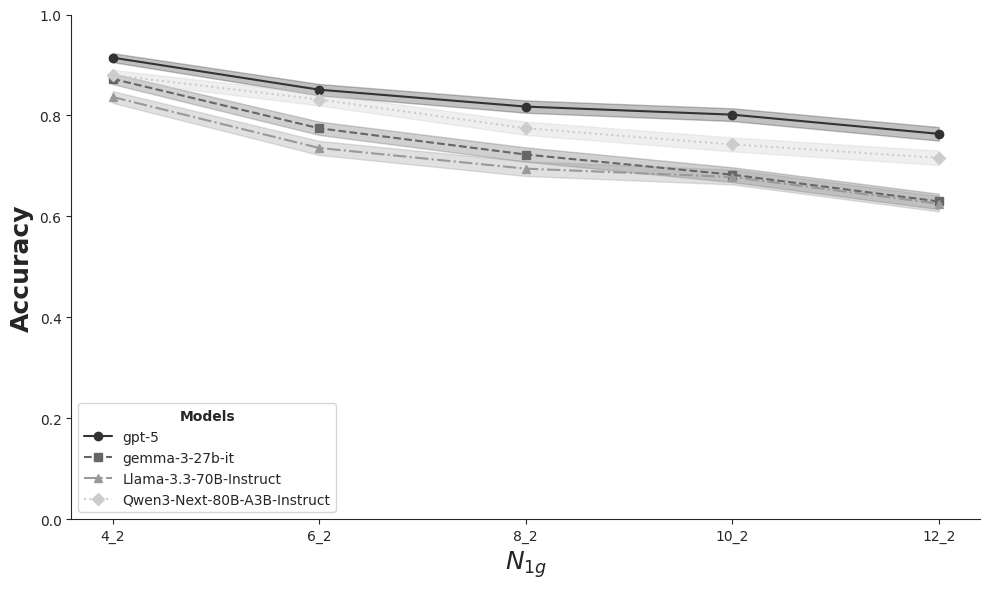

In [7]:
import glob
import matplotlib.pyplot as plt
import seaborn as sns

def plot_accuracy_vs_times_blackwhite_task1(df):
    import matplotlib.pyplot as plt
    import seaborn as sns
    import numpy as np

    plt.figure(figsize=(10, 6), facecolor='none')
    plt.ylim(0, 1)
    sns.set_style("white")
    models = df['model'].unique()
    colors = plt.cm.gray(np.linspace(0.2, 0.8, len(models)))
    linestyles = ['-', '--', '-.', ':']
    markers = ['o', 's', '^', 'D', 'v', 'P', '*']  # 不同形状marker，长度可根据模型数扩展

    for i, model in enumerate(models):
        model_data = df[df['model'] == model].sort_values('times')

        plt.plot(
            model_data['times'],
            model_data['accuracy'],
            marker=markers[i % len(markers)],
            color=colors[i],
            linestyle=linestyles[i % len(linestyles)],
            label=model
        )

        plt.fill_between(
            model_data['times'],
            model_data['accuracy'] - model_data['accuracy_std'],
            model_data['accuracy'] + model_data['accuracy_std'],
            color=colors[i],
            alpha=0.3
        )

    plt.xlabel(r'$N_{1g}$', fontsize=18, fontweight='bold')
    plt.ylabel('Accuracy', fontsize=18, fontweight='bold')
    legend = plt.legend(title='Models')
    legend.set_title("Models", prop={'weight': 'bold'})
    plt.tight_layout()
    ax = plt.gca()
    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)
    ax.spines['left'].set_visible(True)
    ax.spines['bottom'].set_visible(True)
    ax.xaxis.set_ticks_position('bottom')
    ax.yaxis.set_ticks_position('left')
    plt.show()

def plot_accuracy_vs_times_blackwhite_task2(df):
    import matplotlib.pyplot as plt
    import seaborn as sns
    import numpy as np

    plt.figure(figsize=(10, 6), facecolor='none')
    plt.ylim(0, 1)
    sns.set_style("white")
    models = df['model'].unique()
    colors = plt.cm.gray(np.linspace(0.2, 0.8, len(models)))
    linestyles = ['-', '--', '-.', ':']
    markers = ['o', 's', '^', 'D', 'v', 'P', '*']  # 不同形状marker，长度可根据模型数扩展

    for i, model in enumerate(models):
        model_data = df[df['model'] == model].sort_values('times')

        plt.plot(
            model_data['times'],
            model_data['accuracy'],
            marker=markers[i % len(markers)],
            color=colors[i],
            linestyle=linestyles[i % len(linestyles)],
            label=model
        )

        plt.fill_between(
            model_data['times'],
            model_data['accuracy'] - model_data['accuracy_std'],
            model_data['accuracy'] + model_data['accuracy_std'],
            color=colors[i],
            alpha=0.3
        )

    plt.xlabel(r'$N_{2s}$', fontsize=18, fontweight='bold')
    plt.ylabel('Accuracy', fontsize=18, fontweight='bold')
    legend = plt.legend(title='Models')
    legend.set_title("Models", prop={'weight': 'bold'})
    plt.tight_layout()
    ax = plt.gca()
    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)
    ax.spines['left'].set_visible(True)
    ax.spines['bottom'].set_visible(True)
    ax.xaxis.set_ticks_position('bottom')
    ax.yaxis.set_ticks_position('left')
    plt.show()

def plot_accuracy_vs_times_blackwhite_task3(df):
    import matplotlib.pyplot as plt
    import seaborn as sns
    import numpy as np

    plt.figure(figsize=(10, 6), facecolor='none')
    sns.set_style("white")
    models = df['model'].unique()
    colors = plt.cm.gray(np.linspace(0.2, 0.8, len(models)))
    linestyles = ['-', '--', '-.', ':']
    markers = ['o', 's', '^', 'D', 'v', 'P', '*']  # 不同形状marker，长度可根据模型数扩展

    for i, model in enumerate(models):
        model_data = df[df['model'] == model]
        model_data[['part1', 'part2']] = model_data['times'].str.split('_', expand=True).astype(int)
        model_data = model_data.sort_values(by=['part1', 'part2'])
        model_data = model_data.drop(columns=['part1', 'part2'])

        plt.plot(
            model_data['times'],
            model_data['accuracy'],
            marker=markers[i % len(markers)],
            color=colors[i],
            linestyle=linestyles[i % len(linestyles)],
            label=model
        )

        plt.fill_between(
            model_data['times'],
            model_data['accuracy'] - model_data['accuracy_std'],
            model_data['accuracy'] + model_data['accuracy_std'],
            color=colors[i],
            alpha=0.3
        )

    plt.xlabel(r'$N_{1g}$', fontsize=18, fontweight='bold')
    plt.ylabel('Accuracy', fontsize=18, fontweight='bold')
    plt.ylim(0, 1)
    legend = plt.legend(title='Models')
    legend.set_title("Models", prop={'weight': 'bold'})
    plt.tight_layout()
    ax = plt.gca()
    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)
    ax.spines['left'].set_visible(True)
    ax.spines['bottom'].set_visible(True)
    ax.xaxis.set_ticks_position('bottom')
    ax.yaxis.set_ticks_position('left')
    plt.show()

def split_times(input_str):
    times = input_str.split("_")[3]
    return int(times)

def split_combination(input_str):
    combination1 = input_str.split("_")[3]
    combination2 = input_str.split("_")[4]
    return str(combination1) + "_" + str(combination2)

def split_model(input_str):
    model = input_str.split("_")[4].split(".jsonl")[0]
    return model

def split_model_task_3(input_str):
    model = input_str.split("_")[6].split(".jsonl")[0]
    return model

df = pd.DataFrame()
for f in glob.glob("data/extraction_pdf/datasets/SUMMARY/*"):
    if "results_summary_task" in f:
        if "task1" in f:
            df_eval = pd.read_json(f, lines=True)
            df_eval["model"] = df_eval.file_name.apply(split_model)
            df_eval["times"] = df_eval.file_name.apply(split_times)
            df_eval["task"] = "task1"
            df = pd.concat([df, df_eval], ignore_index=True)
        if "task2" in f:
            df_eval = pd.read_json(f, lines=True)
            df_eval["model"] = df_eval.file_name.apply(split_model)
            df_eval["times"] = df_eval.file_name.apply(split_times)
            df_eval["task"] = "task2"
            df = pd.concat([df, df_eval], ignore_index=True)
        if "task3" in f:
            df_eval = pd.read_json(f, lines=True)
            df_eval["model"] = df_eval.file_name.apply(split_model_task_3)
            df_eval["times"] = df_eval.file_name.apply(split_combination)
            df_eval["task"] = "task3"
            df = pd.concat([df, df_eval], ignore_index=True)
       
        # elif "task4" in f:
        #     df_eval = pd.read_json(f, lines=True)
        #     df_eval["model"] = df_eval.file_name.apply(split_model)
        #     df_eval["times"] = df_eval.file_name.apply(split_times)
        #     df = pd.concat([df, df_eval], ignore_index=True)

models_selected = ["gpt-5","Llama-3.3-70B-Instruct", "Qwen3-Next-80B-A3B-Instruct","gemma-3-27b-it"]
df = df[df["model"].isin(models_selected)]

# plot_accuracy_vs_times_blackwhite(df[df["times"].str.contains("_2")])
# plot task1
plot_df = df[df["task"] == "task1"]
plot_df["times"] = plot_df["times"].astype(int)
plot_accuracy_vs_times_blackwhite_task1(plot_df)

# # plot task2
plot_df = df[df["task"] == "task2"]
plot_df["times"] = plot_df["times"].astype(int)
plot_accuracy_vs_times_blackwhite_task2(plot_df)

# # plot task3
plot_df = df[df["task"] == "task3"]
plot_accuracy_vs_times_blackwhite_task3(plot_df[plot_df["times"].str.contains("_2")])

#2")])

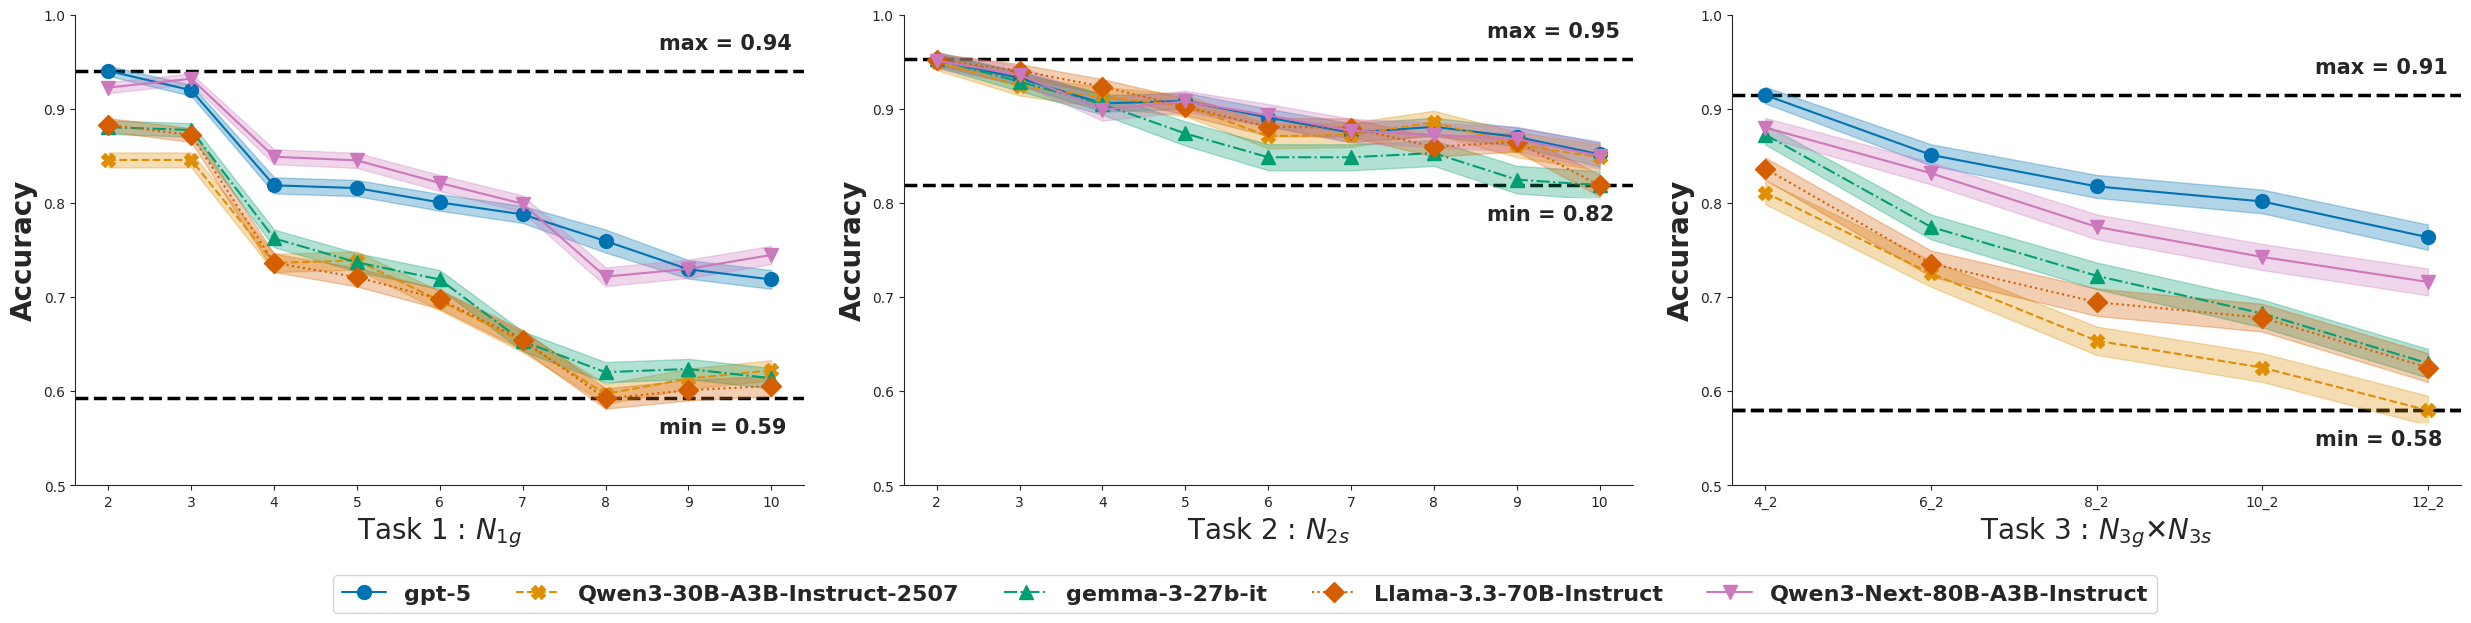

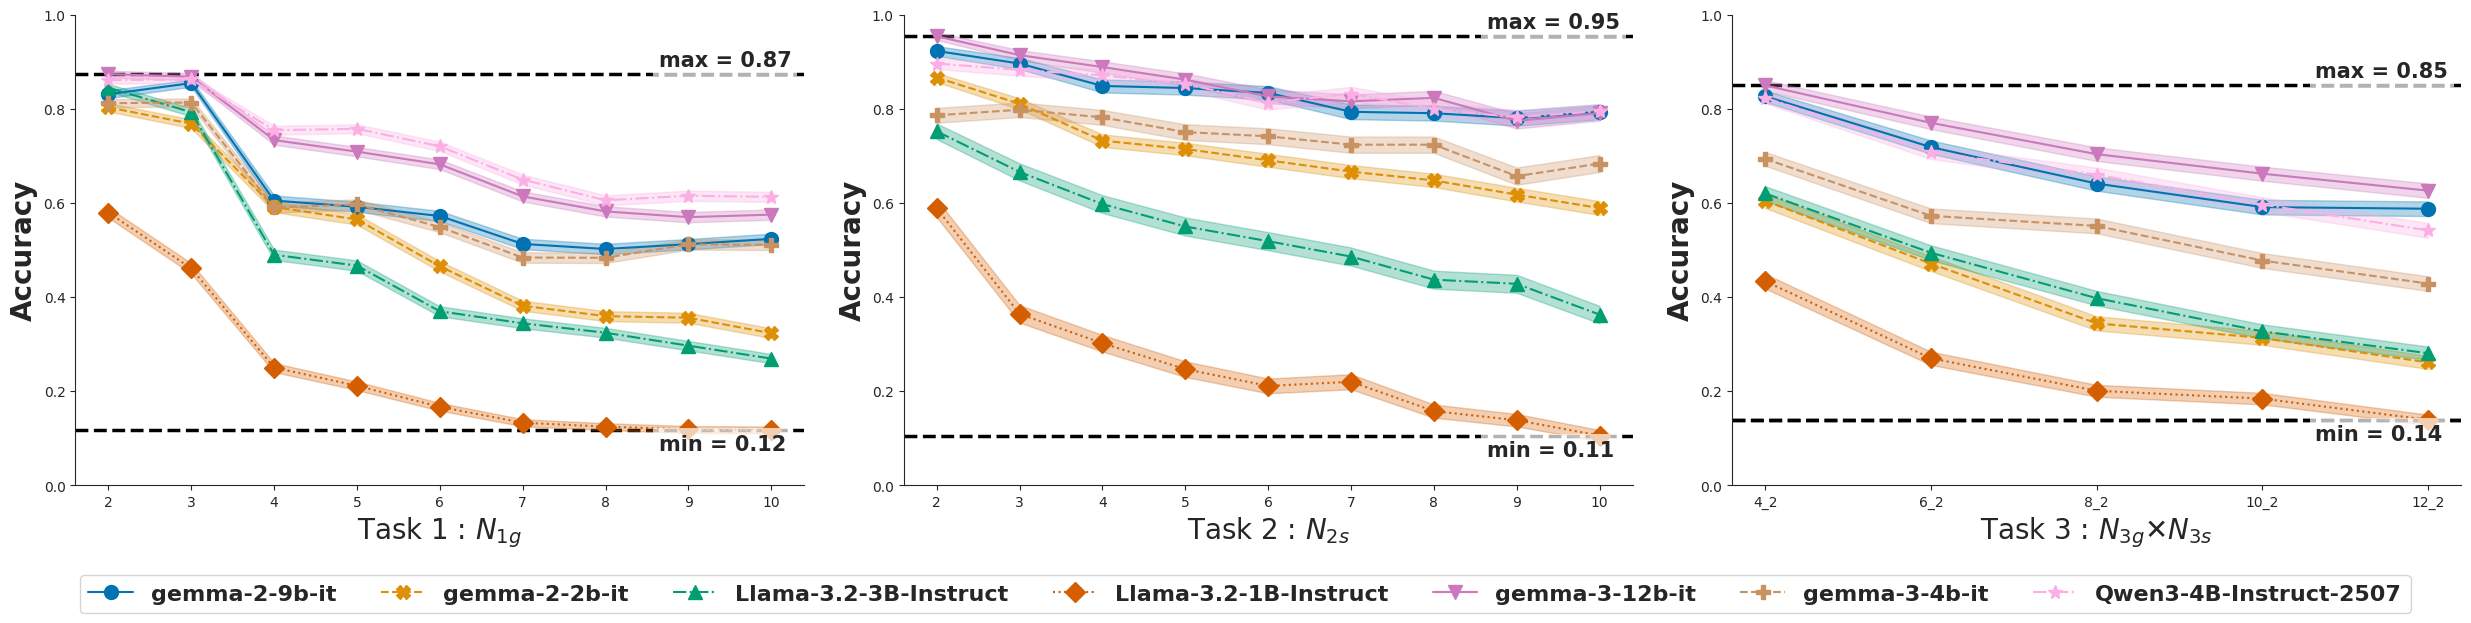

In [ ]:
import glob
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

def plot_accuracy_vs_times_blackwhite_subplot(df_task1, df_task2, df_task3, save_name="summary_plot.png", y_limit=(0.0,1.0)):
    sns.set_style("white")
    models = df_task1['model'].unique()
    colors = plt.cm.gray(np.linspace(0.2, 1.0, len(models)))
    # colors = sns.color_palette("colorblind", n_colors=len(models))
    # tab10 = plt.get_cmap('tab10')
    # colors = [tab10(i % tab10.N) for i in range(len(models))]
    # cmap = plt.get_cmap('tab20')  # 或 'Paired' / 'Set2'
    # colors = [cmap(i % cmap.N) for i in range(len(models))]    # N=20 或 12[web:59][web:61]
    # colors = sns.color_palette("deep", n_colors=len(models)) 
    # colors = sns.color_palette("colorblind", n_colors=len(models))  # 近似 Nature 图风格的克制感[web:63]
    linestyles = ['-', '--', '-.', ':', '-', '--', '-.', ':',"dotted"]
    markers = ['o', 'X', '^', 'D', 'v', 'P', '*', 's', 'h']  

    fig, axes = plt.subplots(1, 3, figsize=(25, 6), facecolor='none')

    task_dfs = [df_task1, df_task2, df_task3]
    task_labels = [r'Task 1 : $N_{1g}$', r'Task 2 : $N_{2s}$', r'Task 3 : $N_{3g} ✕ N_{3s}$']

    for ax, df, xlabel in zip(axes, task_dfs, task_labels):
        all_rows = []
        for i, model in enumerate(models):
            model_data = df[df['model'] == model].copy()

            if df is df_task3:
                model_data[['part1', 'part2']] = model_data['times'].str.split('_', expand=True).astype(int)
                model_data = model_data.sort_values(by=['part1', 'part2'])
                model_data = model_data.drop(columns=['part1', 'part2'])
            else:
                model_data = model_data.sort_values('times')

            ax.plot(
                model_data['times'],
                model_data['accuracy'],
                marker=markers[i % len(markers)],
                color=colors[i],
                markersize=10,          
                markeredgewidth=1.0,    
                linestyle=linestyles[i % len(linestyles)],
                label=model
            )
            ax.fill_between(
                model_data['times'],
                model_data['accuracy'] - model_data['accuracy_std'],
                model_data['accuracy'] + model_data['accuracy_std'],
                color=colors[i],
                alpha=0.3
            )
            tmp = model_data[['times', 'accuracy']].copy()
            tmp['model'] = model
            all_rows.append(tmp)

        all_df = pd.concat(all_rows, ignore_index=True)
        y_min = all_df['accuracy'].min()
        y_max = all_df['accuracy'].max()
        # 画横线（粗 & 虚线）
        ax.axhline(y=y_min, color='black', linestyle='--', linewidth=2.5, zorder=0)  # 粗的虚线[web:9][web:12]
        ax.text(0.8, y_min-0.03, f"min = {y_min:.2f}",
            transform=ax.get_yaxis_transform(),  # x 为轴分数坐标，y 为数据坐标
            ha='left', va='center',
            fontsize=15, fontweight='bold',
            bbox=dict(facecolor='white', edgecolor='none', alpha=0.7))

        ax.axhline(y=y_max, color='black', linestyle='--', linewidth=2.5, zorder=0)  # 粗的虚线[web:9][web:12]
        ax.text(0.8, y_max+0.03, f"max = {y_max:.2f}",
            transform=ax.get_yaxis_transform(),  # x 为轴分数坐标，y 为数据坐标
            ha='left', va='center',
            fontsize=15, fontweight='bold',
            bbox=dict(facecolor='white', edgecolor='none', alpha=0.7))
        
        ax.set_xlabel(xlabel, fontsize=20)
        ax.set_ylabel('Accuracy', fontsize=20, fontweight='bold')
        ax.set_ylim(y_limit)
        ax.spines['top'].set_visible(False)
        ax.spines['right'].set_visible(False)
        ax.spines['left'].set_visible(True)
        ax.spines['bottom'].set_visible(True)
        ax.xaxis.set_ticks_position('bottom')
        ax.yaxis.set_ticks_position('left')
        # ax.legend(title='Models').set_title("Models", prop={'weight': 'bold'})
    # handles, labels = axes[0].get_legend_handles_labels()
    # fig.legend(handles, labels, loc='center right', fontsize=12, frameon=True)
    # fig.tight_layout(rect=[0, 0, 0.85, 1])  # 给右侧留空间
    # plt.savefig(save_name, dpi=300, bbox_inches='tight', transparent=True)
    # plt.show()

    # ===== 新增：计算该子图全局最低点并画横向虚线、加粗、标注其值 =====
    all_df = pd.concat(all_rows, ignore_index=True)
    y_min = all_df['accuracy'].min()
    # 画横线（粗 & 虚线）
    ax.axhline(y=y_min, color='black', linestyle='--', linewidth=2.5, zorder=0)  # 粗的虚线[web:9][web:12]

    handles, labels = axes[0].get_legend_handles_labels()
    # fig.legend(handles, labels, loc='lower center', ncol=len(models), fontsize=12, frameon=True, fontweight='bold')
    legend = fig.legend(
        handles, labels,
        loc='lower center',
        ncol=len(models),
        frameon=True,
        prop={'size': 16, 'weight': 'bold'},
        bbox_to_anchor=(0.5, -0.05)  # 需要时下移到图外
    )
    fig.tight_layout(rect=[0,0.05,1,1])  # 给下方 legend 留空间
    plt.savefig(save_name, dpi=300, bbox_inches='tight', transparent=True)
    plt.show()


# --- 数据处理保持不变 ---
df = pd.DataFrame()
for f in glob.glob("data/extraction_pdf/datasets/SUMMARY/*"):
    if "results_summary_task" in f:
        if "task1" in f:
            df_eval = pd.read_json(f, lines=True)
            df_eval["model"] = df_eval.file_name.apply(split_model)
            df_eval["times"] = df_eval.file_name.apply(split_times)
            df_eval["task"] = "task1"
            df = pd.concat([df, df_eval], ignore_index=True)
        if "task2" in f:
            df_eval = pd.read_json(f, lines=True)
            df_eval["model"] = df_eval.file_name.apply(split_model)
            df_eval["times"] = df_eval.file_name.apply(split_times)
            df_eval["task"] = "task2"
            df = pd.concat([df, df_eval], ignore_index=True)
        if "task3" in f:
            df_eval = pd.read_json(f, lines=True)
            df_eval["model"] = df_eval.file_name.apply(split_model_task_3)
            df_eval["times"] = df_eval.file_name.apply(split_combination)
            df_eval["task"] = "task3"
            df = pd.concat([df, df_eval], ignore_index=True)

models_selected = ["gpt-5","Llama-3.3-70B-Instruct", "Qwen3-Next-80B-A3B-Instruct","gemma-3-27b-it","Qwen3-30B-A3B-Instruct-2507"]
plot_df = df[df["model"].isin(models_selected)]

# --- 准备每个任务的 df ---
df_task1 = plot_df[plot_df["task"] == "task1"].copy()
df_task1["times"] = df_task1["times"].astype(int)

df_task2 = plot_df[plot_df["task"] == "task2"].copy()
df_task2["times"] = df_task2["times"].astype(int)

df_task3 = plot_df[plot_df["task"] == "task3"].copy()
df_task3 = df_task3[df_task3["times"].str.contains("_2")]

# --- 绘制一行三个子图 ---
plot_accuracy_vs_times_blackwhite_subplot(df_task1, df_task2, df_task3, save_name="summary_plot_big.png", y_limit=(0.5,1.0))



models_selected = ["gemma-2-2b-it","gemma-2-9b-it", "gemma-3-4b-it","gemma-3-12b-it","Llama-3.2-1B-Instruct","Llama-3.2-3B-Instruct","Qwen3-4B-Instruct-2507"]
plot_df = df[df["model"].isin(models_selected)]

# --- 准备每个任务的 df ---
df_task1 = plot_df[plot_df["task"] == "task1"].copy()
df_task1["times"] = df_task1["times"].astype(int)

df_task2 = plot_df[plot_df["task"] == "task2"].copy()
df_task2["times"] = df_task2["times"].astype(int)

df_task3 = plot_df[plot_df["task"] == "task3"].copy()
df_task3 = df_task3[df_task3["times"].str.contains("_2")]

# --- 绘制一行三个子图 ---
plot_accuracy_vs_times_blackwhite_subplot(df_task1, df_task2, df_task3, save_name="summary_plot_small.png", y_limit=(0.0,1.0))


In [ ]:
models_all = ["gpt-5","Llama-3.3-70B-Instruct", "Qwen3-Next-80B-A3B-Instruct","gemma-3-27b-it","Qwen3-30B-A3B-Instruct-2507","gemma-2-2b-it","gemma-2-9b-it", "gemma-3-4b-it","gemma-3-12b-it","Llama-3.2-1B-Instruct","Llama-3.2-3B-Instruct","Qwen3-4B-Instruct-2507"]

df_task = df[df["model"].isin(models_all)].copy()

In [ ]:
df_task.columns

Index(['file_name', 'total_samples', 'total_original_samples', 'str_accuracy',
       'str_probs', 'accuracy', 'accuracy_std', 'probs_mean', 'probs_std',
       'model', 'times', 'task'],
      dtype='object')

In [49]:
import glob
df_trans  = pd.DataFrame()
for f in glob.glob("data/performance_eval/*"):
    if "task_eval_translation" in f:
        print (f)
        model_name = f.split("_")[-1].replace(".jsonl","")
        df = pd.read_json(f, lines=True)
        df = df[df["CometScore"]!=-1.0]
        print(f"Number of valid rows: {len(df)}")
        subset = df[~df["task_translation_dict"].isnull()][
            ["CometScore", "CometScoreSmall", "spbleu_score", "chrf_score"]
        ]
        CometScore = subset["CometScore"].mean()

        dict_row = {
            "model": model_name,
            "CometScore": f"{CometScore:.2f}"
        }
        df_row = pd.DataFrame([dict_row])
        df_trans = pd.concat([df_trans, df_row], ignore_index=True)

data/performance_eval/task_eval_translation_20251008_074544_Llama-3.2-1B-Instruct.jsonl
Number of valid rows: 3197
data/performance_eval/task_eval_translation_20251006_004427_Qwen3-Next-80B-A3B-Instruct.jsonl
Number of valid rows: 3352
data/performance_eval/task_eval_translation_20251006_221514_gemma-3-4b-it.jsonl
Number of valid rows: 3352
data/performance_eval/task_eval_translation_20251006_002049_gemma-2-2b-it.jsonl
Number of valid rows: 3352
data/performance_eval/task_eval_translation_20251006_221603_gemma-3-12b-it.jsonl
Number of valid rows: 3352
data/performance_eval/task_eval_translation_20251006_221633_Qwen3-4B-Instruct-2507.jsonl
Number of valid rows: 3352
data/performance_eval/task_eval_translation_20251006_063006_Llama-3.3-70B-Instruct.jsonl
Number of valid rows: 3352
data/performance_eval/task_eval_translation_20251006_122111_gpt-5.jsonl
Number of valid rows: 1303
data/performance_eval/task_eval_translation_20251006_213226_gemma-2-9b-it.jsonl
Number of valid rows: 3352
data

In [50]:
df_task_filtered_task3 = df_task[(df_task["task"] == "task3") & (df_task["times"] == "4_2")]
df_task_filtered_task2 = df_task[(df_task["task"] == "task2") & (df_task["times"] == 2)]
df_task_filtered_task1 = df_task[(df_task["task"] == "task1") & (df_task["times"] == 2)]

In [51]:
df_task_concat = pd.concat([df_task_filtered_task1, df_task_filtered_task2, df_task_filtered_task3], ignore_index=True)


In [52]:
df_summary = pd.merge(df_task_concat,df_trans,on="model",how="left")

In [54]:
df_task_1_2_3 = df_summary.copy()

In [77]:
df = pd.DataFrame()
for f in glob.glob("data/extraction_pdf/datasets/SUMMARY/*"):
    if "results_summary_task" in f:
        if "task4" in f:
            df_task4 = pd.read_json(f, lines=True)

In [78]:
def split_model(input_str):
    model = input_str.split("_")[3].split(".jsonl")[0]
    return model

df_task4["model"] = df_task4.file_name.apply(split_model)
models_all = ["gpt-5","Llama-3.3-70B-Instruct", "Qwen3-Next-80B-A3B-Instruct","gemma-3-27b-it","Qwen3-30B-A3B-Instruct-2507","gemma-2-2b-it","gemma-2-9b-it", "gemma-3-4b-it","gemma-3-12b-it","Llama-3.2-1B-Instruct","Llama-3.2-3B-Instruct","Qwen3-4B-Instruct-2507"]
df_task4 = df_task4[df_task4["model"].isin(models_all)]

In [80]:
df_task4 = df_task4[["model", "accuracy"]]

df_task4.rename(columns={"accuracy": "task4"}, inplace=True)

In [81]:
df_task_1_2_3 = df_task_1_2_3[["model", "task","accuracy"]]

In [82]:
df_flat = df_task_1_2_3.pivot(index='model', columns='task', values='accuracy').reset_index()

In [83]:
df_task4

,model,task4
0,gemma-2-9b-it,0.509314
1,gemma-2-2b-it,0.496078
2,gpt-5,0.608270
3,Qwen3-30B-A3B-Instruct-2507,0.544608
4,gemma-3-27b-it,0.540196
5,Llama-3.3-70B-Instruct,0.509314
6,Llama-3.2-3B-Instruct,0.475000
7,Llama-3.2-1B-Instruct,0.511275
9,gemma-3-12b-it,0.536275
10,gemma-3-4b-it,0.516667


In [84]:
df_task_1_2_3_4 = pd.merge(df_flat, df_task4, on="model", how="left")

In [94]:
df_summary = pd.merge(df_task_1_2_3_4, df_trans, on="model", how="left")

In [95]:
c = df_summary['CometScore'].astype(float)
c_min, c_max = c.min(), c.max()
df_summary['CometScore'] = (c - c_min) / (c_max - c_min + 1e-12)

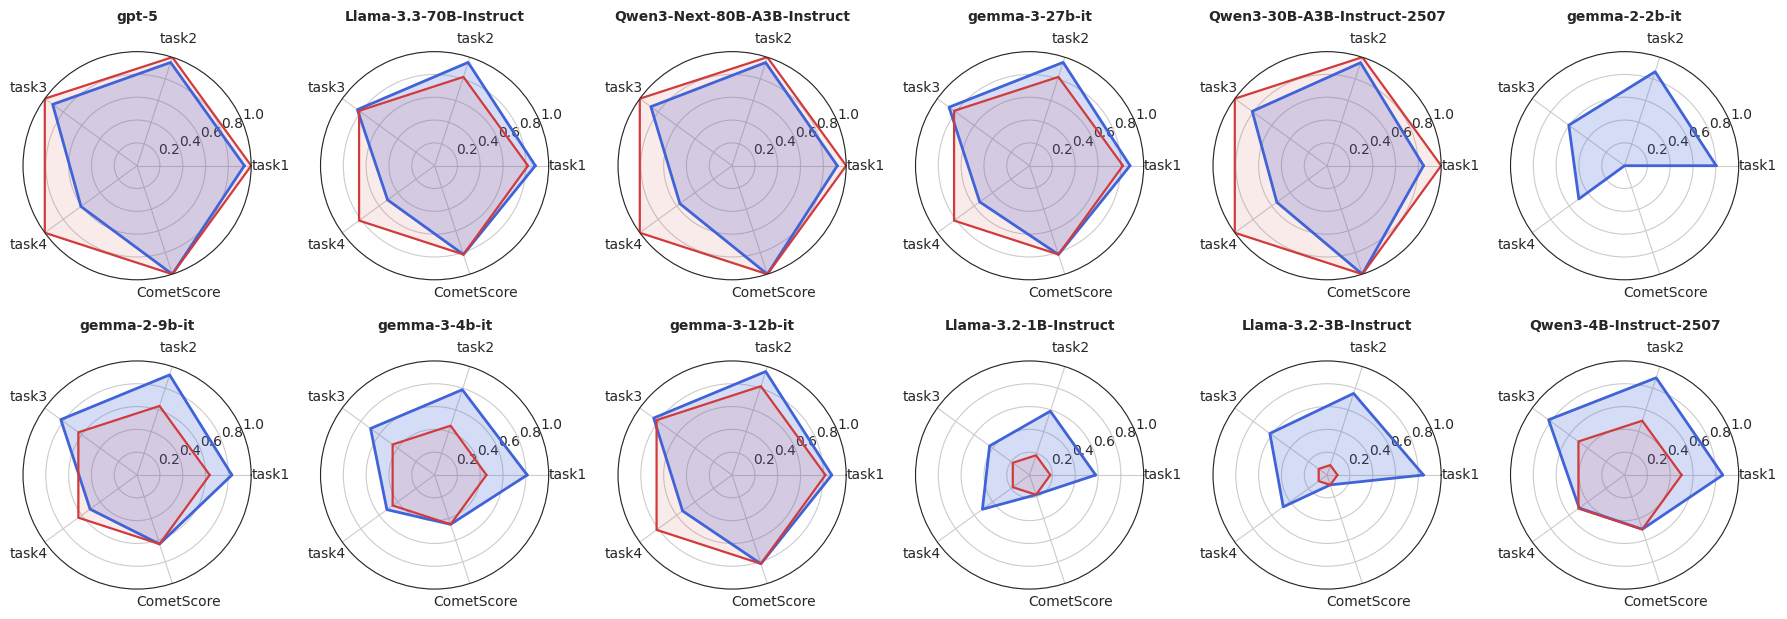

In [103]:
import math
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

models_all = ["gpt-5","Llama-3.3-70B-Instruct", "Qwen3-Next-80B-A3B-Instruct","gemma-3-27b-it","Qwen3-30B-A3B-Instruct-2507","gemma-2-2b-it","gemma-2-9b-it", "gemma-3-4b-it","gemma-3-12b-it","Llama-3.2-1B-Instruct","Llama-3.2-3B-Instruct","Qwen3-4B-Instruct-2507"]

tasks = ['task1','task2','task3','task4','CometScore']
N = len(tasks)
angles = np.linspace(0, 2*np.pi, N, endpoint=False)
angles = np.concatenate([angles, angles[:1]])

# 1) 按照 models_all 设置有序分类，并排序
cat = pd.api.types.CategoricalDtype(categories=models_all, ordered=True)
df_summary['model'] = df_summary['model'].astype(cat)
df_summary = df_summary.sort_values('model')  # 此时顺序严格按 models_all 排列

n_models = len(df_summary)
assert n_models == 12, "not 12 "

rows, cols = 2, 6  # 固定 2*6
fig, axes = plt.subplots(rows, cols, figsize=(18, 6.6), subplot_kw=dict(polar=True))
axes = axes.flatten()

for ax, (_, row) in zip(axes, df_summary.iterrows()):
    vals = row[tasks].values.astype(float)
    vals = np.concatenate([vals, vals[:1]])
    ax.plot(angles, vals, color='#4063D8', lw=2)
    ax.fill(angles, vals, color='#4063D8', alpha=0.22)

    comet = float(row['CometScore'])
    comet_ring = np.full(len(angles), comet)
    ax.plot(angles, comet_ring, color='#D23B3B', lw=1.6)
    ax.fill(angles, comet_ring, color='#D23B3B', alpha=0.10)

    ax.set_thetagrids(np.degrees(angles[:-1]), labels=tasks)
    ax.set_ylim(0, 1.0)
    ax.set_title(str(row['model']), fontsize=10, pad=8, fontweight='bold')

# 清空多余轴（稳妥）
for j in range(len(df_summary), rows*cols):
    fig.delaxes(axes[j])

plt.tight_layout(rect=[0,0,1,0.96])
plt.savefig("summary_radar_plot.png", dpi=300, bbox_inches='tight', transparent=True)
plt.show()


In [104]:
df_summary

,model,task1,task2,task3,task4,CometScore
11,gpt-5,0.940196,0.951957,0.9145,0.608270,1.000000
2,Llama-3.3-70B-Instruct,0.882843,0.951957,0.8365,0.509314,0.818182
5,Qwen3-Next-80B-A3B-Instruct,0.922549,0.950966,0.8800,0.565686,1.000000
9,gemma-3-27b-it,0.880392,0.952452,0.8725,0.540196,0.818182
3,Qwen3-30B-A3B-Instruct-2507,0.845588,0.949480,0.8110,0.544608,1.000000
6,gemma-2-2b-it,0.802941,0.866293,0.6045,0.496078,0.000000
7,gemma-2-9b-it,0.830882,0.922734,0.8265,0.509314,0.636364
10,gemma-3-4b-it,0.811765,0.786033,0.6935,0.516667,0.454545
8,gemma-3-12b-it,0.873529,0.953938,0.8495,0.536275,0.818182
0,Llama-3.2-1B-Instruct,0.579412,0.588410,0.4335,0.511275,0.181818


## Summary Datasets

In [67]:
import pandas as pd

df = pd.read_json("data/performance_eval/task_eval_translation_20251006_081527_Qwen3-30B-A3B-Instruct-2507.jsonl", lines=True)

In [72]:
df["len_char_text_eng"] = df.apply(lambda x: len(x['text_eng']) if pd.notnull(x['text_eng']) else 0, axis=1)


In [73]:
df.groupby("source")["len_char_text_eng"].describe()

,count,mean,std,min,25%,50%,75%,max
source,,,,,,,,
flore200,1012.0,125.606719,41.175428,28.0,98.0,120.0,149.0,297.0
samples_pdf,2040.0,171.634804,21.416202,109.0,157.0,170.0,185.0,262.0
val_300,300.0,429.470000,49.179853,308.0,393.0,423.5,459.0,621.0


In [10]:
import pandas as pd


df = pd.read_json("data/extraction_pdf/datasets/df_samples.jsonl", lines=True )

In [ ]:
df.grammar_points_des6

grammar_points_descriptions
The past participle in Luxembourgish is the non-finite form used to build perfect tenses (present perfect, pluperfect) and to express a resultant state (often with forms of 'sinn' or 'hunn'). To form the perfect, the appropriate auxiliary verb (hunn or sinn) is conjugated and combined with the past participle of the main verb. 'Hunn' is typically used with transitive verbs and many intransitives; 'sinn' is commonly used with verbs of motion or change of state. The past participle can also describe a resultant state when used with a copula (for example, 'ass' + past participle). Pluperfects are formed with the past (preterite) form of the auxiliary plus the past participle. Past participles vary in formation (regular and irregular forms), but their main syntactic roles are to form compound tenses and to function as adjectives or result states.    4
The verb 'stoen' is a Luxembourgish strong (irregular) verb whose principal parts show vowel alternations (ablau

In [13]:
import pandas as pd

df = pd.read_json("data/extraction_pdf/datasets/back_checking_20250930_170933.jsonl", lines=True)

In [ ]:
total_score = 0
gramar_reflection_num = 0
for idx, row in df.iterrows():
    back_checking_dict = row['back_checking_dict']
    translation_score = back_checking_dict.get('translation_score', None)
    gramar_reflection = back_checking_dict.get('grammar_reflection', None)
    total_score += (translation_score )
    if "No" in gramar_reflection:
        gramar_reflection_num += 1

print (f"Average translation score: {total_score/(len(df)*10):.2f}")
print (f"Number of No in gramar_reflection: {1 - gramar_reflection_num/len(df)}:.2f")


Average translation score: 0.79
Number of No in gramar_reflection: 0.060294117647058824


In [21]:
back_checking_dict

{'translation_score': 9,
 'grammar_reflection': 'Yes',
 'false_sentence': 'Fuerscher hunn Quartieren gemellt, an deem Gemeinschaftszenteren, Schoulen a Geschäfter verschidde dominéierend Sproochen benotzen, wat variéiert Méiglechkeeten fir allerdags multilingual Kontakter ënner Awunner schaaft.',
 'false_reason': "Wrong relative connector agreement: used singular/neuter 'an deem' instead of the required dative plural 'an deenen' to match 'Quartieren'."}

In [24]:
gramar_reflection